# <center>**Figure 01 - Supplementary 03 : suNB Compilation**</center>

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
import navis
import flybrains

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set_style("ticks")
from prats_helpers import place_panel_label

import sys
sys.path.append("../Scripts")
from _lineage_palette import (load_lineage_colors,
                              ANTERIOR_LINEAGES,
                              DORSO_POSTERIOR_LINEAGES)

In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

In [3]:
SOMA_FOLDER = "../Analysis_Outputs/EM_Sections"
HOME        = os.environ["PROJECTS_HOME"]

In [4]:
brain    = flybrains.PK_L1CNSsym
neuropil = navis.Volume(flybrains.PK_L1CBNeuropilsym.mesh)
neuropil.color = (0.75, 0.75, 0.75, 0.5)

Load in the suNB

In [5]:
skeletons = glob(f"{HOME}/L1_Skeletons/Skeletons/suNB_Skeletons/*/*/*.swc")
# Read them in
skeletons = navis.read_swc(skeletons, fmt = "{id}.swc")

Importing:   0%|          | 0/154 [00:00<?, ?it/s]

Color each suNB by lineage and split into anterior vs. dorso-posterior groups.

In [6]:
lin_colors = load_lineage_colors(strip_slashes = False)

su = skeletons[skeletons.category == "suNB"]
for skel in su:
    skel.color = lin_colors.get(skel.lineage, "grey")

# Assigning
anterior        = navis.NeuronList([s for s in su if s.lineage in ANTERIOR_LINEAGES])
dorso_posterior = navis.NeuronList([s for s in su if s.lineage in DORSO_POSTERIOR_LINEAGES])

# Right for Anterior
anterior = anterior[anterior.hemisphere == "Right"]
dorso_posterior = dorso_posterior[dorso_posterior.hemisphere == "Left"]

# Color Dict
nb_colors = dict(zip(su.id, su.color))

Loading in counts.

In [7]:
count_df = pd.read_csv("../Analysis_Outputs/Lineage_Stats/Lineage_Counts.csv")

# Remove the Sensory and Bolwigs
count_df = count_df.loc[~(count_df["Lineage"].str.contains("S-")) &
                        ~(count_df["Lineage"].str.contains("Bolwig"))]

# Group by category
count_df = count_df.groupby(["Category", "Hemisphere"])["Count"].sum().reset_index()
count_df

,Category,Hemisphere,Count
0,Dev,Left,22
1,Dev,Right,19
2,Diff,Left,1351
3,Diff,Right,1349
4,SU,Left,518
5,SU,Right,504
6,suNB,Left,72
7,suNB,Right,82


Load cable length.

In [8]:
cable_df = pd.read_csv(f"{HOME}/L1_Skeletons/Analysis_Outputs/Cable_Length.csv")
cable_df

,bodyId,Lineage,Category,Hemisphere,Cable_Length_nm,Cable_Length_um
0,17355888,BAla3/4,SU,Right,39162.620,39.162620
1,17547011,BAla3/4,SU,Right,29327.674,29.327673
2,17546995,BAla3/4,SU,Right,23911.998,23.911999
3,17356020,BAla3/4,SU,Right,49863.855,49.863857
4,17355884,BAla3/4,SU,Right,19214.273,19.214273
...,...,...,...,...,...,...
4336,15691122,MB-PM,Dev,Left,138971.620,138.971620
4337,16053670,MB-PM,Dev,Left,87513.445,87.513440
4338,16448954,MB-PM,Dev,Left,142811.230,142.811230
4339,16448971,MB-PM,Dev,Left,171509.380,171.509370


Figure

Plot neurons:   0%|          | 0/45 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/45 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/45 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/35 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/35 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/35 [00:00<?, ?it/s]

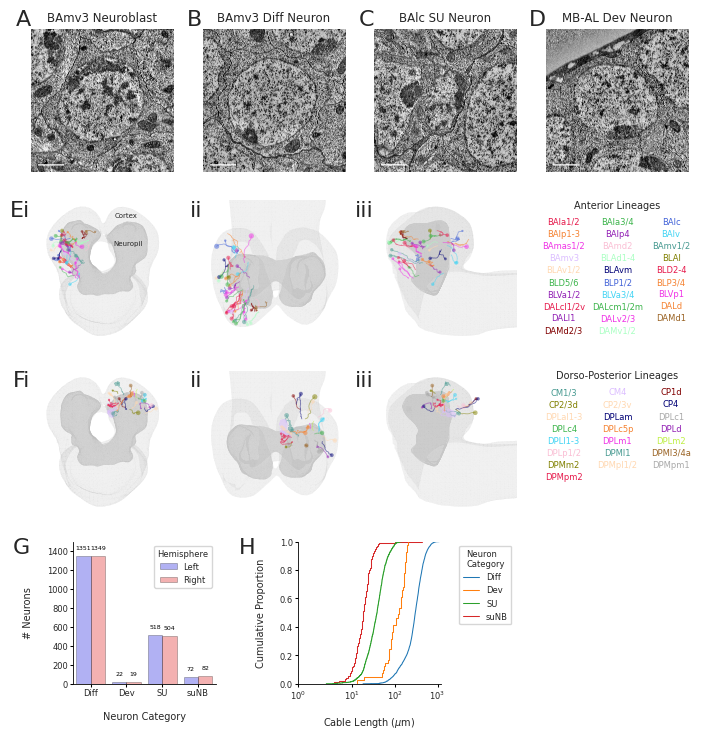

In [10]:
width  = 8.5
height = 8.5
fig, ax = plt.subplots(figsize = (width, height), 
                 nrows = 4,
                 ncols = 4)

# Adjust
for a in ax.flatten():
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)
        
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5
    )

#------------------------------------------------------------------
# SOMA PANELS 
# suNB
img = mpimg.imread(f"{SOMA_FOLDER}/Soma_BAmv3_suNB_Right-cbar.png")          
ax[0, 0].imshow(img, cmap = "grey")
ax[0, 0].set_title("BAmv3 Neuroblast", fontsize = title_fontsize)
ax[0, 0].axis("off")

# Diff
img = mpimg.imread(f"{SOMA_FOLDER}/Soma_BAmv3_Diff-01_Right-cbar.png")          
ax[0, 1].imshow(img, cmap = "grey")
ax[0, 1].set_title("BAmv3 Diff Neuron", fontsize = title_fontsize)
ax[0, 1].axis("off")

# SU
img = mpimg.imread(f"{SOMA_FOLDER}/Soma_BAlc_SU-04_Right-cbar.png")          
ax[0, 2].imshow(img, cmap = "grey")
ax[0, 2].set_title("BAlc SU Neuron", fontsize = title_fontsize)
ax[0, 2].axis("off")

# Dev
img = mpimg.imread(f"{SOMA_FOLDER}/Soma_MB-AL_Dev_Right-cbar.png")          
ax[0, 3].imshow(img, cmap = "grey")
ax[0, 3].set_title("MB-AL Dev Neuron", fontsize = title_fontsize)
ax[0, 3].axis("off")

#------------------------------------------------------------------
# Neuroblast Panels
# Anterior Group
navis.plot2d([brain, neuropil, anterior],
            ax        = ax[1, 0],
            method    = "2d",
            view      = ("x", "-y"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)

navis.plot2d([brain, neuropil, anterior],
            ax        = ax[1, 1],
            method    = "2d",
            view      = ("x", "z"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)

navis.plot2d([brain, neuropil, anterior],
            ax        = ax[1, 2],
            method    = "2d",
            view      = ("z", "-y"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)


# Dorso-posterior Group
navis.plot2d([brain, neuropil, dorso_posterior],
            ax        = ax[2, 0],
            method    = "2d",
            view      = ("x", "-y"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)

navis.plot2d([brain, neuropil, dorso_posterior],
            ax        = ax[2, 1],
            method    = "2d",
            view      = ("x", "z"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)

navis.plot2d([brain, neuropil, dorso_posterior],
            ax        = ax[2, 2],
            method    = "2d",
            view      = ("z", "-y"),
            color     = nb_colors,
            alpha     = 0.5,
            linewidth = 0.6,
            rasterize = True)

# Adjust the limits with the first panel as base
xlim = ax[1, 0].get_xlim()
ylim = ax[1, 0].get_ylim()
ax[1, 1].set_xlim(xlim)
ax[1, 1].set_ylim(xlim) # Square it and the aspect is right
ax[1, 2].set_ylim(ylim)
ax[1, 2].set_xlim(ylim[::-1]) # Square it and the aspect is right 

# Still set it to the Anterior Ones
ax[2, 0].set_xlim(xlim)
ax[2, 0].set_ylim(ylim)
ax[2, 1].set_xlim(xlim)
ax[2, 1].set_ylim(xlim)
ax[2, 2].set_ylim(ylim)
ax[2, 2].set_xlim(ylim[::-1])

# Label Neuropil and Cortex
ax[1, 0].text(72500, 10000,
              s = "Cortex",
              ha = "center", 
              va = "center",
              fontsize = tick_fontsize - 1)

ax[1, 0].text(75000, 35000,
              s = "Neuropil",
              ha = "center", 
              va = "center",
              fontsize = tick_fontsize - 1)

# Equal
for a in ax[1:3, :3].flatten():
    a.set_aspect("equal", adjustable = "datalim")

# Adding the lineage names
col_x    = [-0.75, 0, 0.75]
row_step = 0.17

# Anterior Lineages
for a in [ax[1, 3], ax[2, 3]]:
    a.set_xlim(-1, 1)
    a.set_ylim(-1, 1)

# Anterior Lineages
ax[1, 3].text(0, 1,
              "Anterior Lineages",
              fontsize = label_fontsize,
              ha = "center",
              va = "top")

for i, lin in enumerate(np.unique(anterior.lineage)):
    ax[1, 3].text(col_x[i % 3], 0.7 - (i // 3) * row_step,
            s  = lin,
            ha = "center", 
            va = "center",
            color = lin_colors.get(lin, "grey"),
            fontsize = tick_fontsize)

# Dorso-Posterior Lineages
ax[2, 3].text(0, 1,
              "Dorso-Posterior Lineages",
              fontsize = label_fontsize,
              ha = "center",
              va = "top")

for i, lin in enumerate(np.unique(dorso_posterior.lineage)):
    ax[2, 3].text(col_x[i % 3], 0.7 - (i // 3) * row_step,
            s  = lin,
            ha = "center", 
            va = "center",
            color = lin_colors.get(lin, "grey"),
            fontsize = tick_fontsize)

# Turn Off Axes
for a in ax[1:3, :].flatten():
    a.axis("off")


#------------------------------------------------------------------
# Category Counts
sns.barplot(count_df,
            x = "Category",
            y = "Count",
            hue = "Hemisphere",
            palette   = {"Left": "blue", "Right": "red"},
            alpha     = alpha_hist,
            edgecolor = "black",
            linewidth = linewidth_hist,
            ax        = ax[3, 0],
            order     = ["Diff", "Dev", "SU", "suNB"])

# Labels for the bar
for container in ax[3, 0].containers:
    # container is a BarContainer → has .patches
    ax[3, 0].bar_label(container,
                       fmt      = "%d",
                       padding  = 4,
                       fontsize = tick_fontsize - 1.5,
                       color    = "black")

# Limits
ax[3, 0].set_ylim(0, 1500)
ax[3, 0].set_ylabel("# Neurons", fontsize = label_fontsize, labelpad = labelpad)
ax[3, 0].set_xlabel("Neuron Category", fontsize = label_fontsize, labelpad = labelpad)

# Move legend
sns.move_legend(
    ax[3, 0],
    loc   = "upper right",
    bbox_to_anchor = (1, 1),
    title   = "Hemisphere",
    frameon = True,
    title_fontsize = tick_fontsize,
    fontsize       = tick_fontsize)

#------------------------------------------------------------------
# Cable Length
sns.ecdfplot(cable_df,
             x   = "Cable_Length_um",
             hue = "Category",
             hue_order = ["Diff", "Dev", "SU", "suNB"],
             linewidth = linewidth,
             ax        = ax[3, 1],
             legend    = True)

sns.move_legend(
    ax[3, 1],
    loc   = "upper left",
    bbox_to_anchor = (1.1, 1),
    title   = "Neuron\nCategory",
    frameon = True,
    title_fontsize = tick_fontsize,
    fontsize       = tick_fontsize)

# Limits
ax[3, 1].set_xlim(1, 1200)
ax[3, 1].set_ylabel("Cumulative Proportion", fontsize = label_fontsize, labelpad = labelpad)
ax[3, 1].set_xlabel("Cable Length ($\mu$m)", fontsize = label_fontsize, labelpad = labelpad)

# Log scale
ax[3, 1].set_xscale("symlog")

# Cleanup
for a in [ax[3, 0], ax[3, 1]]:
    # Tick
    a.tick_params(
        axis  = "both",
        which = "major",
        labelsize = tick_fontsize)
    # Despine
    sns.despine(ax = a)

#------------------------------------------------------------------
# Move the bottom panels a little
shift = 0.05
# Barchart
pos = ax[3, 0].get_position()
ax[3, 0].set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])

# ECDF
pos = ax[3, 1].get_position()
ax[3, 1].set_position([pos.x0 + (shift * 2.25), pos.y0, pos.width, pos.height])

# Remove axes
ax[3, 2].axis("off")
ax[3, 3].axis("off")

#------------------------------------------------------------------
# Panel Labels
label_kwargs = dict(fontsize = 16, va = "bottom", ha = "right")
place_panel_label(fig, ax[0, 0], "A", shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 1], "B", shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 2], "C", shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 3], "D", shx = 0, shy = 0, label_kwargs = label_kwargs)

# Volumes
label_kwargs["va"] = "top"
place_panel_label(fig, ax[1, 0], "Ei",  shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 1], "ii",  shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 2], "iii", shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 0], "Fi",  shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 1], "ii",  shx = 0, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 2], "iii", shx = 0, shy = 0, label_kwargs = label_kwargs)

# Stats
place_panel_label(fig, ax[3, 0], "G", shx = -0.05, shy = 0.005, label_kwargs = label_kwargs)
place_panel_label(fig, ax[3, 1], "H", shx = -0.05, shy = 0.005, label_kwargs = label_kwargs)

#------------------------------------------------------------------
# Place this just into Analysis Outputs
plt.savefig("../Analysis_Outputs/Figure_01_Supplementary-03_suNB-and-Cable.pdf",
            bbox_inches = "tight",
            dpi         = 1200)

# <center>**हो गया दोस्तों!!!**</center>